# Анализ рекламных источников и поведения пользователей мобильной игры "Космические братья"

Презентация - https://disk.yandex.ru/i/N58iVzFHlgR9aA

Цель исследования - анализ поведения пользователей в зависимости от источника перехода в игру. 

Анализ проводится на основании данных о событиях, совершенных в мобильной игре «Космические братья», а также информации о рекламных активностях и источниках привлечения пользователей. 

В датасете с данными о событиях представлены данные по игре пользователей на первом уровне. В датасете содержатся данные первых пользователей приложения — когорты пользователей, которые начали пользоваться приложением в период с 4 по 10 мая включительно. 

1. [Получение данных и изучение общей информации](#loading)
2. [Предобработка данных](#preprocessing)
3. [Исследовательский анализ данных](#analysis)
     * [Рассчет показателей по каждому пользователю - время привлечения, количество постороенных объектов, источник перехода в игру, стоимость привлечения, способ завершения уровня, время завершения уровня](#calculation)
     * [Рекламные расходы в разбивке по каналам привлечения](#cost)
     * [Динамика количества новых пользователей и стоимость привлечения 1 пользователя в разбивке по источникам](#count_new_user)
     * [Структура пользователей по способу прохождения уровня](#users)
     * [Распределение пользователей по времени завершения уровня и количеству построенных объектов](#users_2)
     
4. [Анализ влияния источника перехода в игру на поведение пользователя](#transition_source)
     * [Время завершения уровня пользователем в разбивке по источникам перехода в игру](#time)
     * [Количество построенных объектов одним пользователем в разбивке  по источникам перехода в игру](#buildings)
     * [Способы завершения уровня в разбивке по источникам перехода в игру](#methods)
     
5. [Проверка статистических гипотез](#hypotheses)
     * [Гипотеза 1. Время завершения уровня различается в зависимости способа прохождения уровня](#hypothes_1)
     * [Гипотеза 2. Среднее количество объектов, построенных одним пользователем, различается в зависимости от источника траффика](#hypothes_2)
     
6. [Общий вывод](#conclusion)

## Получение данных и изучение общей информации<a id="loading"></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [6]:
game_actions = pd.read_csv('datasets/game_actions.csv')
ad_costs = pd.read_csv('datasets/ad_costs.csv')
user_source = pd.read_csv('datasets/user_source.csv')
game_actions.info()
display(game_actions.head(5))
ad_costs.info()
display(ad_costs.head(5))
user_source.info()
display(user_source.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135640 entries, 0 to 135639
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   event_datetime  135640 non-null  object
 1   event           135640 non-null  object
 2   building_type   127957 non-null  object
 3   user_id         135640 non-null  object
 4   project_type    1866 non-null    object
dtypes: object(5)
memory usage: 5.2+ MB


,event_datetime,event,building_type,user_id,project_type
0,2020-05-04 00:00:01,building,assembly_shop,55e92310-cb8e-4754-b622-597e124b03de,NaN
1,2020-05-04 00:00:03,building,assembly_shop,c07b1c10-f477-44dc-81dc-ec82254b1347,NaN
2,2020-05-04 00:00:16,building,assembly_shop,6edd42cc-e753-4ff6-a947-2107cd560710,NaN
3,2020-05-04 00:00:16,building,assembly_shop,92c69003-d60a-444a-827f-8cc51bf6bf4c,NaN
4,2020-05-04 00:00:35,building,assembly_shop,cdc6bb92-0ccb-4490-9866-ef142f09139d,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   source  28 non-null     object 
 1   day     28 non-null     object 
 2   cost    28 non-null     float64
dtypes: float64(1), object(2)
memory usage: 800.0+ bytes


,source,day,cost
0,facebook_ads,2020-05-03,935.882786
1,facebook_ads,2020-05-04,548.354480
2,facebook_ads,2020-05-05,260.185754
3,facebook_ads,2020-05-06,177.982200
4,facebook_ads,2020-05-07,111.766796


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13576 entries, 0 to 13575
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  13576 non-null  object
 1   source   13576 non-null  object
dtypes: object(2)
memory usage: 212.2+ KB


,user_id,source
0,0001f83c-c6ac-4621-b7f0-8a28b283ac30,facebook_ads
1,00151b4f-ba38-44a8-a650-d7cf130a0105,yandex_direct
2,001aaea6-3d14-43f1-8ca8-7f48820f17aa,youtube_channel_reklama
3,001d39dc-366c-4021-9604-6a3b9ff01e25,instagram_new_adverts
4,002f508f-67b6-479f-814b-b05f00d4e995,facebook_ads


В исследовании используется три датасета - `game_actions`, `ad_costs` и `user_source`. В `game_actions` содержится информация об активности пользователей в игре. `ad_costs` - информация о рекламных активностях. `user_source` - источники привлечения пользователей.  
Пропуски есть только в датасете `game_actions`. В датасетах `game_actions` и `ad_costs` есть колонки с датами у которых не верно назначени тип данных (object вместо datetime).

## Предобработка данных <a id="preprocessing"></a>

In [3]:
#обработка пропусков
game_actions.isnull().sum()

event_datetime         0
event                  0
building_type       7683
user_id                0
project_type      133774
dtype: int64

Пропуски в датасете `game_actions` связаны с что не при каждом event должны быть заполнены все колонки. Например, building_type заполняется только если event = building. Поэтому пропуски нужно оставить.

In [4]:
#обработка дубликатов
for name, table in [['game_actions', game_actions], ['ad_costs', ad_costs], ['user_source', user_source]]:
    print(f'Количество дубликатов в {name} - {table.duplicated().sum()}')

#дубликаты в датасете game_actions   
game_actions[game_actions.duplicated()]
game_actions.drop_duplicates(inplace=True)

#проверка удаления дубликата
print(f'Количество дубликатов в game_actions после удаления - {game_actions.duplicated().sum()}')

Количество дубликатов в game_actions - 1
Количество дубликатов в ad_costs - 0
Количество дубликатов в user_source - 0
Количество дубликатов в game_actions после удаления - 0


Дубликат есть только в датасете `game_actions`. Вероятнее всего это ошибка в данных. Время событий фиксируется до секунды, а в течение одной секунды один и тот же пользователь не может построить два объекта. Поэтому дубликат нужно удалить. 

In [5]:
#замена типов данных на datetime
game_actions['event_datetime'] = pd.to_datetime(game_actions['event_datetime'], format='%Y-%m-%d %H:%M:%S')
ad_costs['day'] = pd.to_datetime(ad_costs['day'], format='%Y-%m-%d').dt.date
display(game_actions.dtypes)
ad_costs.dtypes

event_datetime    datetime64[ns]
event                     object
building_type             object
user_id                   object
project_type              object
dtype: object

source     object
day        object
cost      float64
dtype: object

В датасетах `game_actions` и `ad_costs` нужно заменить тип данных object на datetime.

In [6]:
#проверка наличия ошибок в данных
#проверка диапазонов дат
print(f'Минимальная дата game_actions - {game_actions.event_datetime.min()}, максимальная дата - {game_actions.event_datetime.max()}')
print(f'Минимальная дата ad_costs - {ad_costs.day.min()}, максимальная дата - {ad_costs.day.max()}')

#проверка уникальных значений колонок game_actions
for col in ['event', 'building_type', 'project_type']:
    print('-'* 25)
    print(col, game_actions[col].sort_values().unique())

#проверка уникальных значений колонок ad_costs
print('-'* 25)
print(f'ad_costs.source - {ad_costs.source.sort_values().unique()}')
print(f'Минимальное значение cost - {ad_costs.cost.min()}, максимальное значение сost - {ad_costs.cost.max()}')
  
#проверка уникальных значений колонок user_source
print('-'* 25)
print(f'user_source.source - {user_source.source.sort_values().unique()}')     

Минимальная дата game_actions - 2020-05-04 00:00:01, максимальная дата - 2020-06-05 12:32:49
Минимальная дата ad_costs - 2020-05-03, максимальная дата - 2020-05-09
-------------------------
event ['building' 'finished_stage_1' 'project']
-------------------------
building_type ['assembly_shop' 'research_center' 'spaceport' nan]
-------------------------
project_type ['satellite_orbital_assembly' nan]
-------------------------
ad_costs.source - ['facebook_ads' 'instagram_new_adverts' 'yandex_direct'
 'youtube_channel_reklama']
Минимальное значение cost - 23.314669267402746, максимальное значение сost - 969.1393939421928
-------------------------
user_source.source - ['facebook_ads' 'instagram_new_adverts' 'yandex_direct'
 'youtube_channel_reklama']


Минимальная дата в датасете `ad_costs` на один день раньше, чем минимальная дата в `game_actions`. Это связано с тем, что реклама оплачивается за один день до размещения. Поэтому для корректного анализа данных нужно добавить один день к колонке `ad_costs['day']`.

В остальных данных ошибок и несоответствий не выявлено. 

In [7]:
#добавление одного дня к датам в ad_costs
print(f'Минимальная дата ad_costs - {ad_costs.day.min()}, максимальная дата - {ad_costs.day.max()}')
ad_costs['day']  = ad_costs['day'] + pd.Timedelta(days=1)
print(f'Минимальная дата после добавления 1 дня ad_costs - {ad_costs.day.min()}, максимальная дата - {ad_costs.day.max()}')

Минимальная дата ad_costs - 2020-05-03, максимальная дата - 2020-05-09
Минимальная дата после добавления 1 дня ad_costs - 2020-05-04, максимальная дата - 2020-05-10


В данных не было выявлено существенных ошибок. Названия колонок указаны корректно, даты соответствуют условию задачи.
Был удален один дубликат в датасете `game_actions`.
Заменен тип данных на datetime в `ad_costs['day']` и `game_actions['event_datetime']`. 
Добавлен один день к данным в колонке `ad_costs['day']`.

## Исследовательский анализ данных  <a id="analysis"></a>  

### Рассчет показателей по каждому пользователю - время привлечения, количество постороенных объектов, источник перехода в игру, стоимость привлечения, способ завершения уровня, время завершения уровня  <a id="calculation"></a>  

In [8]:
#расчет даты и времени привлечения клиента и количества построенных зданий
users = game_actions.groupby('user_id', as_index=False).agg({'event_datetime':['min', 'max'],
                                                             'building_type':'count'})
users.columns = ['user_id', 'date_start', 'date_end', 'build_count']
users['day'] = users['date_start'].dt.date

#добавление в сгруппированую таблицу источника привлечения пользователя
users = pd.merge(users, user_source, left_on='user_id', right_on='user_id')

#рассчет стоимости привлечения одного пользователя 
users_count = users.groupby(['day', 'source'], as_index=False)['user_id'].count()
ad_costs_group = ad_costs.groupby(['day', 'source'], as_index=False)['cost'].sum()

cost_per_user = pd.merge(ad_costs_group, users_count, left_on=['day','source'], right_on=['day','source'])
cost_per_user.rename(columns={'user_id':'users_count'}, inplace=True)
cost_per_user['cost_per_user'] = cost_per_user['cost']/cost_per_user['users_count']

#добавление стоимости привлечения одного пользователя в сгруппированную таблицу
users = pd.merge(users, cost_per_user[['day','source', 'cost_per_user']], left_on=['day','source'], right_on=['day','source'])
users.head(5)

,user_id,date_start,date_end,build_count,day,source,cost_per_user
0,0001f83c-c6ac-4621-b7f0-8a28b283ac30,2020-05-06 01:07:37,2020-05-20 11:26:06,13,2020-05-06,facebook_ads,0.754162
1,01303c2e-7de1-4742-8c3e-daf182b67b9f,2020-05-06 07:05:11,2020-05-08 22:30:49,4,2020-05-06,facebook_ads,0.754162
2,0136963c-c45c-4edb-92d8-205bd50a4d36,2020-05-06 14:00:20,2020-05-25 08:56:48,10,2020-05-06,facebook_ads,0.754162
3,018793d6-38c8-450a-bd54-8c181d920f1a,2020-05-06 07:05:52,2020-05-24 23:52:53,12,2020-05-06,facebook_ads,0.754162
4,01e2b256-4519-493f-b010-4a90a2755245,2020-05-06 22:16:07,2020-05-21 04:52:31,9,2020-05-06,facebook_ads,0.754162


In [9]:
#добавление способа завершения уровня
#через реализацию проекта
users_project = game_actions.query('project_type == project_type')['user_id']
        
#через победу над первым врагом
users_victory = game_actions.query('event == "finished_stage_1"')
users_victory = game_actions.loc[(game_actions['event'] == "finished_stage_1")
                                & (~game_actions['user_id'].isin(users_project))]['user_id']

#добавление признака "способ завершения уровня" в группированную таблицу  
conditions = [
    (users['user_id'].isin(users_project)),
    (users['user_id'].isin(users_victory))
]
choices = ['project', 'victory']
users['way_end_level'] =np.select(conditions, choices, default='not_finished')

#рассчет точного времени завершения уровня и количества дней 
users['time_finished'] = (
    users.query('way_end_level != "not_finished"')['date_end'] 
    - users.query('way_end_level != "not_finished"')['date_start']
)
users['days_finished'] = users['time_finished'].dt.days

users.head(5)

,user_id,date_start,date_end,build_count,day,source,cost_per_user,way_end_level,time_finished,days_finished
0,0001f83c-c6ac-4621-b7f0-8a28b283ac30,2020-05-06 01:07:37,2020-05-20 11:26:06,13,2020-05-06,facebook_ads,0.754162,not_finished,NaT,NaN
1,01303c2e-7de1-4742-8c3e-daf182b67b9f,2020-05-06 07:05:11,2020-05-08 22:30:49,4,2020-05-06,facebook_ads,0.754162,not_finished,NaT,NaN
2,0136963c-c45c-4edb-92d8-205bd50a4d36,2020-05-06 14:00:20,2020-05-25 08:56:48,10,2020-05-06,facebook_ads,0.754162,project,18 days 18:56:28,18.0
3,018793d6-38c8-450a-bd54-8c181d920f1a,2020-05-06 07:05:52,2020-05-24 23:52:53,12,2020-05-06,facebook_ads,0.754162,project,18 days 16:47:01,18.0
4,01e2b256-4519-493f-b010-4a90a2755245,2020-05-06 22:16:07,2020-05-21 04:52:31,9,2020-05-06,facebook_ads,0.754162,not_finished,NaT,NaN


### Рекламные расходы в разбивке по каналам привлечения  <a id="cost"></a>  

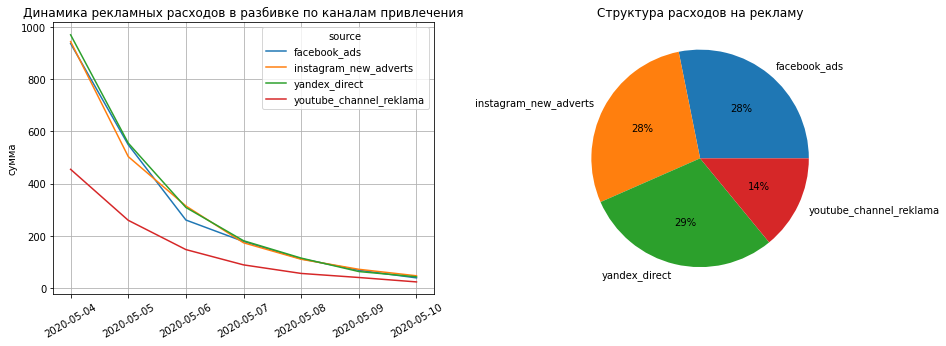

In [10]:
fig, ax = plt.subplots(figsize = (15, 5))

ad_costs.pivot_table(index = 'day', 
                  columns = 'source', 
                  values = 'cost', 
                  aggfunc='sum'
                 ).plot(grid=True, ax=plt.subplot(1,2,1))
plt.title('Динамика рекламных расходов в разбивке по каналам привлечения')
plt.xticks(rotation=30)
plt.xlabel('')
plt.ylabel('сумма')

ad_costs.groupby('source')['cost'].sum().plot.pie(autopct='%1.0f%%', ax=plt.subplot(1,2,2))
plt.title('Структура расходов на рекламу')
plt.ylabel('')

plt.show()

Расходы на рекламу снижаются по экспоненте по всем каналам привлечения. Максимальные расходы на рекламу были в первый день когорты. Рекламный бюджет был распределен по четырем направлениям. Три направления получили примерно одинаковые доли бюджета `instagram`(28%), `facebook`(28%) и `yandex`(29%) и одно направление получило в два раза меньше - `youtube`(14%).

### Динамика количества новых пользователей и стоимость привлечения 1 пользователя в разбивке по источникам <a id="count_new_user"></a> 

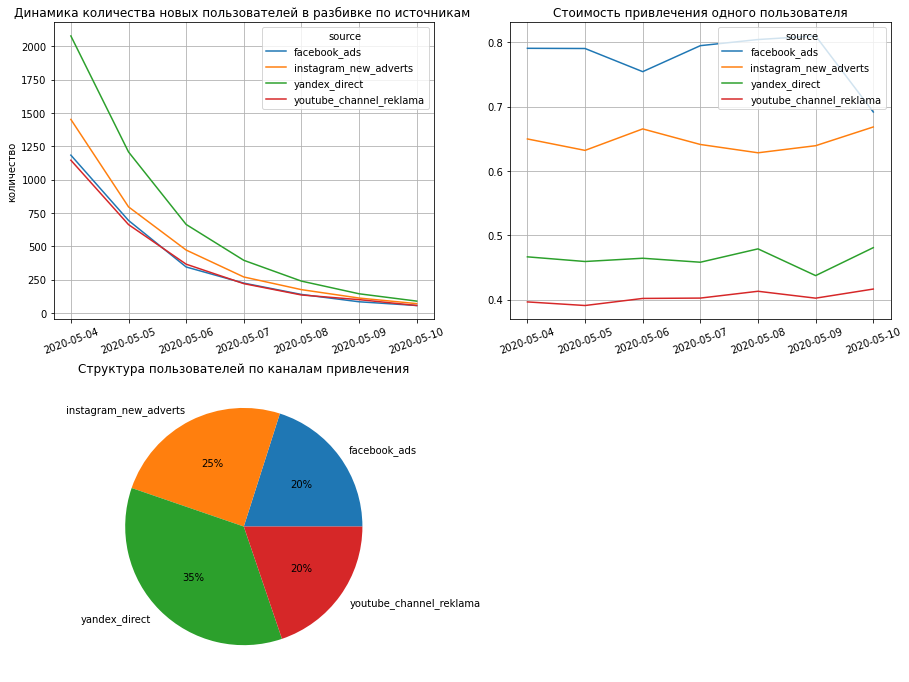

In [11]:
fig, ax = plt.subplots(figsize = (15, 12))

users.pivot_table(index = 'day', 
                  columns = 'source', 
                  values = 'user_id', 
                  aggfunc='count').plot(grid=True, ax=plt.subplot(2,2,1))
plt.title('Динамика количества новых пользователей в разбивке по источникам ')
plt.xticks(rotation=20)
plt.xlabel('')
plt.ylabel('количество')

users.pivot_table(index = 'day', 
                  columns = 'source', 
                  values = 'cost_per_user', 
                  aggfunc='mean'
                 ).plot(grid=True, ax=plt.subplot(2,2,2))
plt.title('Стоимость привлечения одного пользователя')
plt.xticks(rotation=20)
plt.xlabel('')


users.groupby('source')['user_id'].count().plot.pie(autopct='%1.0f%%',
                                                   ax=plt.subplot(2,2,3))
plt.title('Структура пользователей по каналам привлечения')
plt.ylabel('')

plt.show()

Основная доля пользователей данной когорты была привлечена в 4 и 5 мая. Дальше динамика привлечения пользователей повторяет график рекламных расходов. 

Самым выгодным каналом привлечения (с самой низкой стоимостью привлечения одного пользователя) является `youtube_channel_reklama`. Второй по стоимости привлечения одного пользователя - `yandex_direct`. Самый дорогой канал привлечения - `facebook_ads`.

### Структура пользователей по способу прохождения уровня <a id="users"></a> 

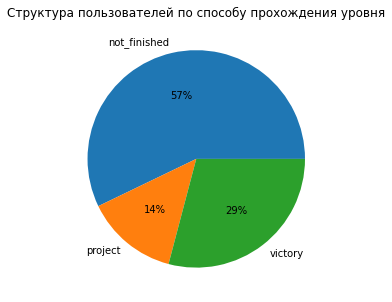

In [12]:
fig, ax = plt.subplots(figsize = (15, 5))
users.groupby('way_end_level')['user_id'].count().plot.pie(autopct='%1.0f%%')
plt.title('Структура пользователей по способу прохождения уровня')
plt.ylabel('')

plt.show()

57% пользователей не завершили первый уровень игры. Среди завершивших первый уровень две трети пользователей победили первого врага и одна треть - реализовали проект.

### Распределение пользователей по времени завершения уровня и количеству построенных объектов <a id="users_2"></a>  

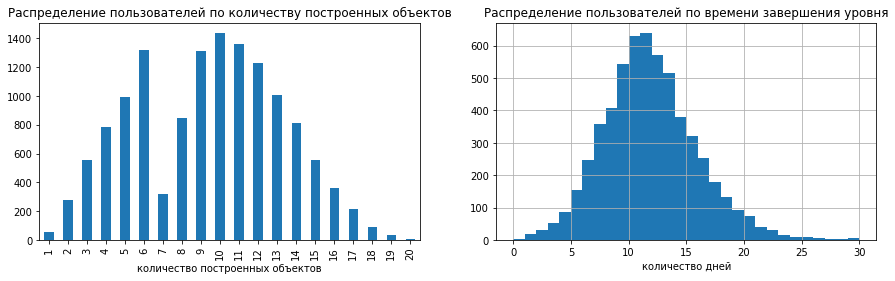

In [13]:
#Распределение пользователей по количеству построенных объектов
fig, ax = plt.subplots(figsize = (15, 4))

users.groupby('build_count')['user_id'].count().plot.bar(ax=plt.subplot(1,2,1))
plt.xlabel('количество построенных объектов')
plt.title('Распределение пользователей по количеству построенных объектов')

#Распределение пользователей по времени завершения уровня
users['days_finished'].hist(bins=30,  ax=plt.subplot(1,2,2))
plt.title('Распределение пользователей по времени завершения уровня')
plt.xlabel('количество дней')
plt.show()

Распределение пользователей по времени завершения уровня(в днях) близко по форме к нормальному распределению. С пиком в 11-12 дней. 

Распределение пользователей по количеству построенных объектов также близко по форме к нормальному распределению, за исключением "провала" на 7 и 8 объектах, пик приходится на 9-11 объектов. Максимум пользователи построили 20 объектов, минимум - 1 объект. 

## Анализ влияния источника перехода в игру на поведение пользователя <a id="transition_source"></a>

### Время завершения уровня пользователем в разбивке по источникам перехода в игру <a id="time"></a>

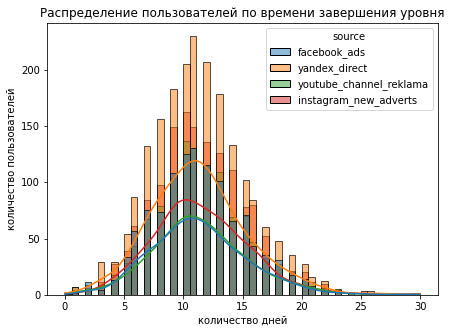

In [14]:
plt.figure(figsize=(7,5))
sns.histplot(data=users, x='days_finished', hue='source', kde=True)
plt.title('Распределение пользователей по времени завершения уровня')
plt.xlabel('количество дней')
plt.ylabel('количество пользователей')
plt.show()

Распределение пользователей по времени завершения уровня (в днях) не зависит от источника прехода в игру. Все графики распределения имеют похожую форму с пиком на уровне 10-11 дней. То есть больше всего пользователей завершает уровень за 10-11 дней не зависимо от источника перехода в игру. 

<div class="alert alert-warning">
<b>Комментарий ревьюера:</b>⛅️ 

График не очень удобно читать, ниже более удобные ящики 
</div>

### Количество построенных объектов одним пользователем в разбивке  по источникам перехода в игру <a id="buildings"></a>  

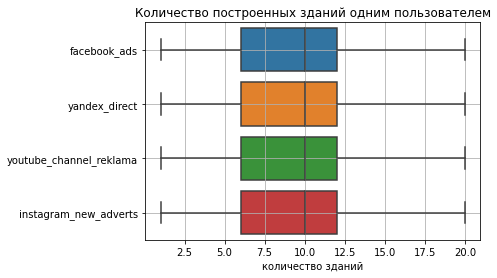

,source,build_count
0,facebook_ads,9.59
1,instagram_new_adverts,9.51
2,yandex_direct,9.35
3,youtube_channel_reklama,9.30


In [15]:
sns.boxplot(data=users, x='build_count', y='source')
plt.title('Количество построенных зданий одним пользователем')
plt.ylabel('')
plt.xlabel('количество зданий')
plt.grid()
plt.show()

users.groupby('source', as_index=False)['build_count'].mean().round(2)

Графики практически идентичны. Медиана количества объектов находится на уровне 10 для всех источников траффика.  50% всех пользователей строят от 6 до 12 зданий. 

Средние значения количества построенных объектов отличаются незначительно. Меньше всего строят пользователи перешедшие в игру с `youtube_channel_reklama` (9.3 объекта на пользователя) . Больше всего  - с `facebook_ads`(9.59 объекта на пользователя).

### Способы завершения уровня в разбивке по источникам перехода в игру  <a id="methods"></a> 

In [16]:
pd.pivot_table(data=users, 
               index='source', 
               columns='way_end_level', 
               values='user_id', 
               aggfunc='count').apply(lambda x: (x * 100) / sum(x), axis=1).round(2)

way_end_level,not_finished,project,victory
source,,,
facebook_ads,57.81,14.34,27.84
instagram_new_adverts,56.20,14.22,29.58
yandex_direct,57.61,12.87,29.52
youtube_channel_reklama,56.85,14.11,29.04


Структура пользователей по способу завершения уровней практически не меняется в зависимости от источника перехода в игру. Больше всего доля пользователей не завершивших первый уровень среди пришедших с `facebook_ads`, меньше всего - `instagram_new_adverts`. Больше всего доля пользователей завершивших первый уровень через реализацию проекта среди пришедших с `facebook_ads`, меньше всего - `yandex_direct`.

Таким образом, поведения пользователя незначительно отличается в зависимости от источника перехода - по среднему количеству построенных объектов, и по способу завершения уровня.<br>
Пользователи, пришедшие с `facebook_ads` реже пользователей с других каналов завершают первый уровень, чаще завершают уровень через реализацию проекта. <br>
Пользователи, пришедшие с `instagram_new_adverts` чаще других пользователей завершают первый уровень, чаще других завершают превый уровень через победу над первым врагом.<br>
Пользователи, пришедшие с `yandex_direct` практически также как и пользователи `facebook_ads` завершают превый уровень, при этом реже других пользователей завершают уровень через реализацию проекта.<br>
Пользователи, пришедшие с `youtube_channel_reklama` по показателям находятся примерно в середине. 

## Проверка статистических гипотез <a id="hypotheses"></a>

### Гипотеза 1. Время завершения уровня различается в зависимости от способа прохождения уровня <a id="hypothes_1"></a>

Нулевая гипотеза: время завершения уровня одинаковое для двух способов завершения уровня 

Альтернативная гипотеза: время завершения уровня различается для двух способов завершения уровня 

In [17]:
sample_1 = users.query('way_end_level == "project"')['days_finished']
sample_2 = users.query('way_end_level == "victory"')['days_finished']

alpha = .05
results = st.ttest_ind(sample_1, sample_2)

print('p-значение: ', results.pvalue)

if results.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение:  1.8882835392370263e-97
Отвергаем нулевую гипотезу


Для проверки гипотезы используем метод st.ttest_ind, так как мы сравниваем средние значения двух генеральных совокупностей по взятым из них выборкам. Так как выборки разного размера, укажем параметр equal_var = False.


Таким образом на уровне значимости 5% есть основания отвергнуть нулевую гипотезу о равенстве времени завершения уровня для двух способов в пользу альтернативной гипотезы.

### Гипотеза 2.  Количество объектов, построенных одним пользователем, различается в зависимости от источника траффика <a id="hypothes_2"></a>

Bсего есть четыре источника перехода пользователя в игру - `facebook_ads`, `yandex_direct`, `youtube_channel_reklama` и `instagram_new_adverts`. Для проверки гипотеза о различии количества построенных одним пользователем объектов нужно попарно протестировать 4 выборки. 

Таким образом, нужно составить и проверить 6 нулевых гипотез. 

Нулевая гипотеза 1: Количество объектов, построенных одним пользователем одинаковое для каналов привлечения: `facebook_ads and yandex_direct`<br>
Альтернативная гипотеза 1: Количество объектов, построенных одним пользователем различное для каналов привлечения: `facebook_ads and yandex_direct`

Нулевая гипотеза 2: Количество объектов, построенных одним пользователем одинаковое для каналов привлечения: `facebook_ads and youtube_channel_reklama` <br>
Альтернативная гипотеза 2: Количество объектов, построенных одним пользователем различное для каналов привлечения: `facebook_ads and youtube_channel_reklama`

Нулевая гипотеза 3: Количество объектов, построенных одним пользователем одинаковое для каналов привлечения: `facebook_ads and instagram_new_adverts` <br>
Альтернативная гипотеза 3: Количество объектов, построенных одним пользователем различное для каналов привлечения: `facebook_ads and instagram_new_adverts`

Нулевая гипотеза 4: Количество объектов, построенных одним пользователем одинаковое для каналов привлечения: `yandex_direct and youtube_channel_reklama` <br>
Альтернативная гипотеза 4: Количество объектов, построенных одним пользователем различное для каналов привлечения: `yandex_direct and youtube_channel_reklama`

Нулевая гипотеза 5: Количество объектов, построенных одним пользователем одинаковое для каналов привлечения: `yandex_direct and instagram_new_adverts` <br>
Альтернативная гипотеза 5: Количество объектов, построенных одним пользователем различное для каналов привлечения: `yandex_direct and instagram_new_adverts` 

Нулевая гипотеза 6: Количество объектов, построенных одним пользователем одинаковое для каналов привлечения: `youtube_channel_reklama and instagram_new_adverts`<br>
Альтернативная гипотеза 6: Количество объектов, построенных одним пользователем различное для каналов привлечения: `youtube_channel_reklama and instagram_new_adverts` 

In [18]:
sample_1 = users.query('source == "facebook_ads"')['build_count']
sample_2 = users.query('source == "yandex_direct"')['build_count']
sample_3 = users.query('source == "youtube_channel_reklama"')['build_count']
sample_4 = users.query('source == "instagram_new_adverts"')['build_count']

alpha = .05

sample_list = [[1, 'facebook_ads > yandex_direct', sample_1, sample_2], 
               [2, 'facebook_ads > youtube_channel_reklama', sample_1, sample_3], 
               [3, 'facebook_ads > instagram_new_adverts', sample_1, sample_4], 
               [4, 'yandex_direct > youtube_channel_reklama', sample_2, sample_3], 
               [5, 'instagram_new_adverts > yandex_direct', sample_4, sample_2],
               [6, 'instagram_new_adverts > youtube_channel_reklama', sample_4, sample_3]]

for number, name, a, b in sample_list:
    results = st.ttest_ind(a, b)
    print(f'Проверка гипотезы {number}, альтернативная гипотеза {name}')
    print('p-значение: ', results.pvalue)
    if results.pvalue/2 < alpha and a.mean() > b.mean(): 
        print('Отвергаем нулевую гипотезу')
    else:
        print('Не получилось отвергнуть нулевую гипотезу')
    print('-'*30)

Проверка гипотезы 1, альтернативная гипотеза facebook_ads > yandex_direct
p-значение:  0.010411759321497693
Отвергаем нулевую гипотезу
------------------------------
Проверка гипотезы 2, альтернативная гипотеза facebook_ads > youtube_channel_reklama
p-значение:  0.006588846148210501
Отвергаем нулевую гипотезу
------------------------------
Проверка гипотезы 3, альтернативная гипотеза facebook_ads > instagram_new_adverts
p-значение:  0.4185321366657372
Не получилось отвергнуть нулевую гипотезу
------------------------------
Проверка гипотезы 4, альтернативная гипотеза yandex_direct > youtube_channel_reklama
p-значение:  0.5972890424874877
Не получилось отвергнуть нулевую гипотезу
------------------------------
Проверка гипотезы 5, альтернативная гипотеза instagram_new_adverts > yandex_direct
p-значение:  0.06989780662351834
Отвергаем нулевую гипотезу
------------------------------
Проверка гипотезы 6, альтернативная гипотеза instagram_new_adverts > youtube_channel_reklama
p-значение:  0

Для проверки гипотез я использовала односторонний t-тест Стьюдента.<br>
По итогам тестов на уровне значимости 5% есть основания отвергнуть нулевые гипотезы 1, 2, 5 и 6  в пользу альтернативных гипотез. Нулевые гипотезы 3 и 4 не отвергнуты. 

Таким образом, с вероятностью 95% среднее количество построенных объектов пользователями пришедшими с `facebook_ads` больше, чем у пользователей пришедших с `yandex_direct` и `youtube_channel_reklama`.<br>
И c вероятностью 95% среднее количество построенных объектов пользователями пришедшими с `instagram_new_adverts` больше, чем у пользователей пришедших с `yandex_direct` и `youtube_channel_reklama`.

## Общий вывод <a id="conclusion"></a>

1. Пользователи приходят в игру через четыре канала `yandex_direct`, `youtube_channel_reklama`, `facebook_ads` и `instagram_new_adverts`. Наибольшая доля пользователей пришла в игру через `yandex_direct`(35%).
2. Самая низкая цена привлечения одного пользователя у каналов `yandex_direct` и `youtube_channel_reklama`.
3. Больше половины пользователей не завершает первый уровень (57%). Треть пользователей завершивших первый уровень завершает его через реализацию проекта, две трети  - через подберу над первым врагом. 
4. Время завершения уровня пользователем различается в зависимости от способы его завершения. 
5. Поведение пользователей незначительно отличается в зависимости от канала привлечения. Так как показ рекламы планируется на экране с выбором объекта постройки, важным фактором является количество построенных объектов пользователем. 
По данному показателю есть небольшие, но статистически значимые(на уровне значимости 5%) отличия по каналам привлечения. Больше всего объектов строят пользователи с `facebook_ads` и `instagram_new_adverts`. 
Но так как стоимость привлечения одного пользователя через эти каналы больше, чем через другие каналы, нужно сравнить ожидаемую доходность пользователя и затраты на его привлечение. 